# 06 · Hypothesentest — Favorita

## 0 · Imports & Setup

In [1]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sys
sys.path.append(os.path.abspath('../03_src'))

from utilis import mape, rmse, run_sarimax, run_prophet, run_xgb, run_lgbm, to_nf_format, compute_metrics, load_preds
from config import PROCESSED, FINAL, TARGET_COL, FEATURE_COLS, EXOG_COLS, STAT_EXOG, HIST_EXOG, TRAIN_END, VAL_END, LOOKBACK, HORIZON, MODELL_ORDER, MODELL_COLORS, PRED_COLS, RESULTS, FILE_NAMES


## 1 - Daten laden

In [2]:
df = pl.read_parquet(FINAL / 'final_dataset.parquet')

train     = df.filter(pl.col('date') <= TRAIN_END)
val       = df.filter((pl.col('date') > TRAIN_END) & (pl.col('date') <= VAL_END))
test      = df.filter(pl.col('date') > VAL_END)
train_val = df.filter(pl.col('date') <= VAL_END)

stores = sorted(df['store_nbr'].unique().to_list())

print(f'Train:     {train.shape}  {train["date"].min()} → {train["date"].max()}')
print(f'Val:       {val.shape}    {val["date"].min()} → {val["date"].max()}')
print(f'Test:      {test.shape}   {test["date"].min()} → {test["date"].max()}')
print(f'Stores:    {len(stores)}')

Train:     (70114, 37)  2013-01-29 → 2016-12-31
Val:       (7965, 37)    2017-01-01 → 2017-05-31
Test:      (4104, 37)   2017-06-01 → 2017-08-15
Stores:    54


## 2 · Ausgangsdatensatz

In [5]:
models_cfg = {
    'XGBoost':  'pred_xgb',
    'LightGBM': 'pred_lgbm',
    'PatchTST': 'pred_patchtst',
    'NHITS':    'pred_nhits',
    'SARIMAX':  'pred_sarimax',
    'Prophet':  'pred_prophet',
}
models_cfg

{'XGBoost': 'pred_xgb',
 'LightGBM': 'pred_lgbm',
 'PatchTST': 'pred_patchtst',
 'NHITS': 'pred_nhits',
 'SARIMAX': 'pred_sarimax',
 'Prophet': 'pred_prophet'}

In [6]:
base = (
    test.select(['store_nbr', 'date', TARGET_COL])
    .rename({TARGET_COL: 'y_true'})
    .to_pandas()
)


In [7]:
for name, col in models_cfg.items():
    fname = f'test_{name.lower()}.parquet'
    try:
        pred_df = pl.read_parquet(RESULTS / fname).to_pandas()
        base = base.merge(pred_df[['store_nbr', 'date', col]],
                          on=['store_nbr', 'date'], how='left')
    except FileNotFoundError:
        print(f'Nicht gefunden: {fname}')

In [8]:

stores_pd = pl.read_parquet(PROCESSED / 'stores.parquet').to_pandas()
base = base.merge(stores_pd[['store_nbr', 'type', 'cluster']],
                  on='store_nbr', how='left')
base

,store_nbr,date,y_true,pred_xgb,pred_lgbm,pred_patchtst,pred_nhits,pred_sarimax,pred_prophet,type,cluster
0,1,2017-06-01,1815,1795.973267,1806.805553,1620.258057,1996.739380,1602.027703,1685.763841,D,13
1,1,2017-06-02,1925,1970.621460,1931.810898,1591.179443,1751.152832,1454.307586,1702.832804,D,13
2,1,2017-06-03,1420,1416.773804,1409.372455,1235.956543,1689.111694,1240.680557,1246.257371,D,13
3,1,2017-06-04,525,521.328369,535.106902,717.624329,897.827393,545.854603,459.782668,D,13
4,1,2017-06-05,1883,1882.316528,1894.626787,1547.486206,1635.100586,1669.458555,1676.592816,D,13
...,...,...,...,...,...,...,...,...,...,...,...
4099,54,2017-08-11,768,778.329041,774.983223,830.489929,1196.948242,771.595969,754.592989,C,3
4100,54,2017-08-12,903,903.930603,898.194325,941.826172,1378.807861,946.317499,932.948913,C,3
4101,54,2017-08-13,1054,1048.668091,1050.275014,992.396790,1444.500732,1084.098506,1100.898020,C,3
4102,54,2017-08-14,818,811.730530,816.891367,942.807007,1266.947998,822.844112,822.234089,C,3


In [10]:
# ── Metriken je Store ─────────────────────────────────────
store_metrics = []
for store_id, grp in base.groupby('store_nbr'):
    for model_name, col in models_cfg.items():
        if col not in grp.columns or grp[col].isna().all():
            continue
        mask   = grp[col].notna() & grp['y_true'].notna()
        y_true = grp.loc[mask, 'y_true'].values
        y_pred = grp.loc[mask, col].values
        store_metrics.append({
            'store_nbr':  store_id,
            'model':      model_name,
            'store_type': grp['type'].iloc[0],
            'MAE':        mean_absolute_error(y_true, y_pred),
            'RMSE':       rmse(y_true, y_pred),
            'MAPE':       mape(y_true, y_pred),
            'std_true':   y_true.std(),
            'acf_lag7':   pd.Series(y_true).autocorr(lag=7),
        })

metrics_df = pd.DataFrame(store_metrics)

# ── Gesamtübersicht ───────────────────────────────────────
summary = metrics_df.groupby('model')[['MAE', 'RMSE', 'MAPE']].mean().round(2)
print(summary.sort_values('MAE'))

             MAE    RMSE   MAPE
model                          
XGBoost     9.00   11.88   0.54
LightGBM    9.66   12.45   0.59
SARIMAX   105.96  135.87   6.71
PatchTST  109.17  137.42   7.45
Prophet   248.39  300.35  12.93
NHITS     249.33  283.98  18.46


### H1: Wenn keine filialspezifische Normalisierung angewendet wird, dann erzielen Gradient-Boosting-Verfahren bei rechtsschiefen Transaktionsdaten mit Extremwerten eine höhere Prognosegenauigkeit als Deep-Learning-Architekturen.

H1: GB vs. Deep Learning – MAE / RMSE
            MAE   RMSE
model                 
XGBoost     9.0   11.9
LightGBM    9.7   12.4
PatchTST  109.2  137.4
NHITS     249.3  284.0


C:\Users\maxkr\AppData\Local\Temp\ipykernel_20780\1328455858.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=h1_df, x='model', y=metric, order=h1_models,
C:\Users\maxkr\AppData\Local\Temp\ipykernel_20780\1328455858.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=h1_df, x='model', y=metric, order=h1_models,


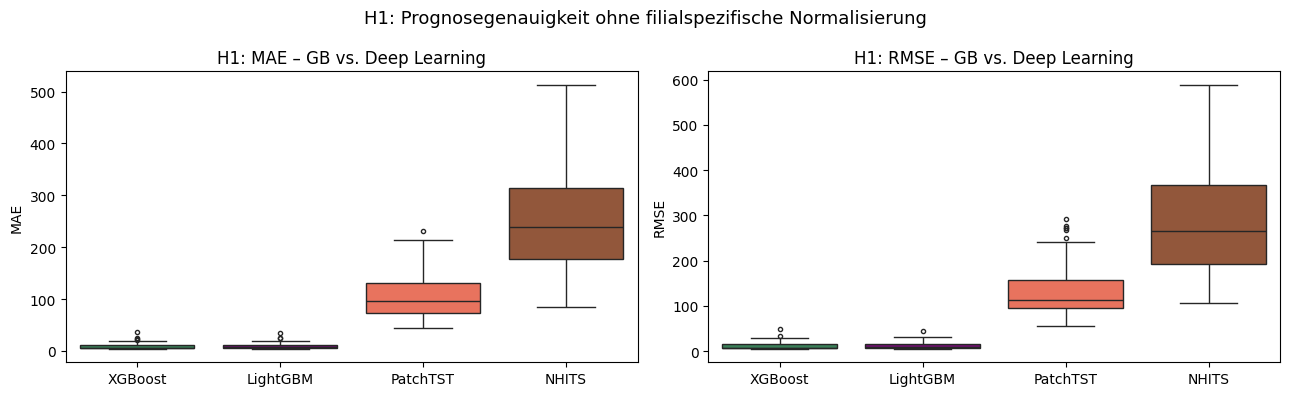

In [11]:
print('H1: GB vs. Deep Learning – MAE / RMSE')

h1_models = ['XGBoost', 'LightGBM', 'PatchTST', 'NHITS']
h1_df     = metrics_df[metrics_df['model'].isin(h1_models)]

print(h1_df.groupby('model')[['MAE', 'RMSE']].mean().round(1).sort_values('MAE'))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for i, metric in enumerate(['MAE', 'RMSE']):
    sns.boxplot(data=h1_df, x='model', y=metric, order=h1_models,
                palette=[MODELL_COLORS[m] for m in h1_models],
                flierprops={'markersize': 3}, ax=axes[i])
    axes[i].set_title(f'H1: {metric} – GB vs. Deep Learning', fontsize=12)
    axes[i].set_xlabel('')
plt.suptitle('H1: Prognosegenauigkeit ohne filialspezifische Normalisierung',
             fontsize=13)
plt.tight_layout()
plt.show()

### H2: Wenn Feiertagsereignisse im Trainingszeitraum nur selten auftreten, dann weisen featuregetriebene Modelle durch explizite Kalender-Features eine geringere Fehlerquote bei der Feiertagsprognose auf als sequenzbasierte Deep-Learning-Architekturen.

In [12]:
hol_national = pd.read_parquet(FINAL / 'holiday_features.parquet')
hol_national

,date,is_national_holiday
0,2013-01-02,False
1,2013-01-03,False
2,2013-01-04,False
3,2013-01-05,True
4,2013-01-06,False
...,...,...
1675,2017-08-11,True
1676,2017-08-12,False
1677,2017-08-13,False
1678,2017-08-14,False


In [10]:
hol_national[hol_national.is_national_holiday == True].date.unique()

array([datetime.date(2013, 1, 5), datetime.date(2013, 1, 12),
       datetime.date(2013, 2, 11), datetime.date(2013, 2, 12),
       datetime.date(2013, 4, 29), datetime.date(2013, 5, 1),
       datetime.date(2013, 5, 11), datetime.date(2013, 5, 12),
       datetime.date(2013, 5, 24), datetime.date(2013, 8, 10),
       datetime.date(2013, 10, 11), datetime.date(2013, 11, 2),
       datetime.date(2013, 11, 3), datetime.date(2013, 12, 21),
       datetime.date(2013, 12, 22), datetime.date(2013, 12, 23),
       datetime.date(2013, 12, 24), datetime.date(2013, 12, 26),
       datetime.date(2013, 12, 31), datetime.date(2014, 3, 3),
       datetime.date(2014, 3, 4), datetime.date(2014, 4, 18),
       datetime.date(2014, 5, 1), datetime.date(2014, 5, 10),
       datetime.date(2014, 5, 11), datetime.date(2014, 5, 24),
       datetime.date(2014, 6, 12), datetime.date(2014, 6, 15),
       datetime.date(2014, 6, 20), datetime.date(2014, 6, 25),
       datetime.date(2014, 6, 28), datetime.date(2014

In [13]:
base['date'] = base['date'].astype(str)
hol_national['date'] = hol_national['date'].astype(str)
base = base.merge(hol_national, on='date', how='left')
base

,store_nbr,date,y_true,pred_xgb,pred_lgbm,pred_patchtst,pred_nhits,pred_sarimax,pred_prophet,type,cluster,is_national_holiday
0,1,2017-06-01,1815,1795.973267,1806.805553,1620.258057,1996.739380,1602.027703,1685.763841,D,13,False
1,1,2017-06-02,1925,1970.621460,1931.810898,1591.179443,1751.152832,1454.307586,1702.832804,D,13,False
2,1,2017-06-03,1420,1416.773804,1409.372455,1235.956543,1689.111694,1240.680557,1246.257371,D,13,False
3,1,2017-06-04,525,521.328369,535.106902,717.624329,897.827393,545.854603,459.782668,D,13,False
4,1,2017-06-05,1883,1882.316528,1894.626787,1547.486206,1635.100586,1669.458555,1676.592816,D,13,False
...,...,...,...,...,...,...,...,...,...,...,...,...
4099,54,2017-08-11,768,778.329041,774.983223,830.489929,1196.948242,771.595969,754.592989,C,3,True
4100,54,2017-08-12,903,903.930603,898.194325,941.826172,1378.807861,946.317499,932.948913,C,3,False
4101,54,2017-08-13,1054,1048.668091,1050.275014,992.396790,1444.500732,1084.098506,1100.898020,C,3,False
4102,54,2017-08-14,818,811.730530,816.891367,942.807007,1266.947998,822.844112,822.234089,C,3,False


In [14]:
hol_records = []
h2_models = ['XGBoost', 'LightGBM', 'PatchTST', 'NHITS']
for model_name, col in {m: models_cfg[m] for m in h2_models}.items():
    if col not in base.columns:
        continue
    for is_hol, grp in base.groupby('is_national_holiday'):
        mask   = grp[col].notna() & grp['y_true'].notna()
        y_true = grp.loc[mask, 'y_true'].values
        y_pred = grp.loc[mask, col].values
        print(model_name, is_hol, len(y_true))
        hol_records.append({
            'model':      model_name,
            'is_national_holiday': 'Feiertag' if is_hol else 'Normal',
            'MAE':        mean_absolute_error(y_true, y_pred),
        })

XGBoost False 4050
XGBoost True 54
LightGBM False 4050
LightGBM True 54
PatchTST False 3975
PatchTST True 53
NHITS False 3975
NHITS True 53


is_national_holiday  Feiertag  Normal  Anstieg (%)
model                                             
LightGBM                 12.5     9.6         29.4
NHITS                   362.1   247.8         46.1
PatchTST                199.3   108.0         84.6
XGBoost                  11.4     9.0         27.7


C:\Users\maxkr\AppData\Local\Temp\ipykernel_20780\2670741698.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=pivot.reset_index(), x='model', y='Anstieg (%)',


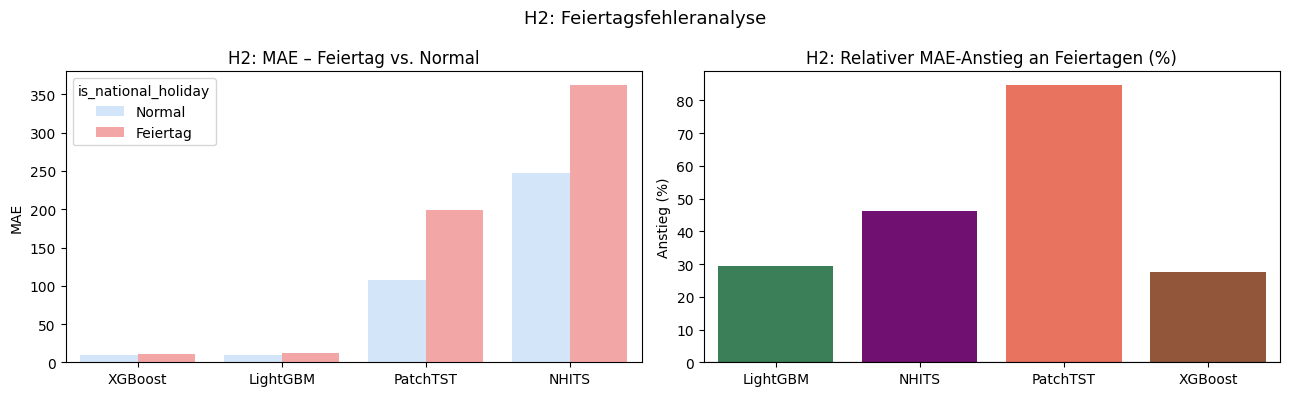

In [16]:
hol_metrics = pd.DataFrame(hol_records)

pivot = hol_metrics.pivot(index='model', columns='is_national_holiday', values='MAE')
pivot['Anstieg (%)'] = ((pivot['Feiertag'] - pivot['Normal'])
                         / pivot['Normal'] * 100).round(1)
print(pivot.round(1))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.barplot(data=hol_metrics, x='model', y='MAE', hue='is_national_holiday',
            hue_order=['Normal', 'Feiertag'],
            palette={'Normal': '#cce5ff', 'Feiertag': '#ff9999'},
            ax=axes[0])
axes[0].set_title('H2: MAE – Feiertag vs. Normal', fontsize=12)
axes[0].set_xlabel('')

sns.barplot(data=pivot.reset_index(), x='model', y='Anstieg (%)',
            palette=[MODELL_COLORS[m] for m in h2_models], ax=axes[1])
axes[1].set_title('H2: Relativer MAE-Anstieg an Feiertagen (%)', fontsize=12)
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_xlabel('')

plt.suptitle('H2: Feiertagsfehleranalyse', fontsize=13)
plt.tight_layout()
plt.show()

### H3: Wenn stark autokorrelierte Zeitreihenabschnitte vorliegen, dann bildet die Deep-Learning-Architekturen die Dynamiken ohne explizites Feature Engineering ebenso präzise oder präziser ab als Gradient-Boosting-Verfahren.

H3: Stark autokorrelierte Stores – DL vs. GB (MAPE)
Stores mit ACF Lag 7 > 0.7: 32
model
XGBoost      0.50
LightGBM     0.55
PatchTST     7.10
NHITS       17.66
Name: MAPE, dtype: float64


C:\Users\maxkr\AppData\Local\Temp\ipykernel_20780\3334690310.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=h3_df, x='model', y='MAPE', order=h3_models,


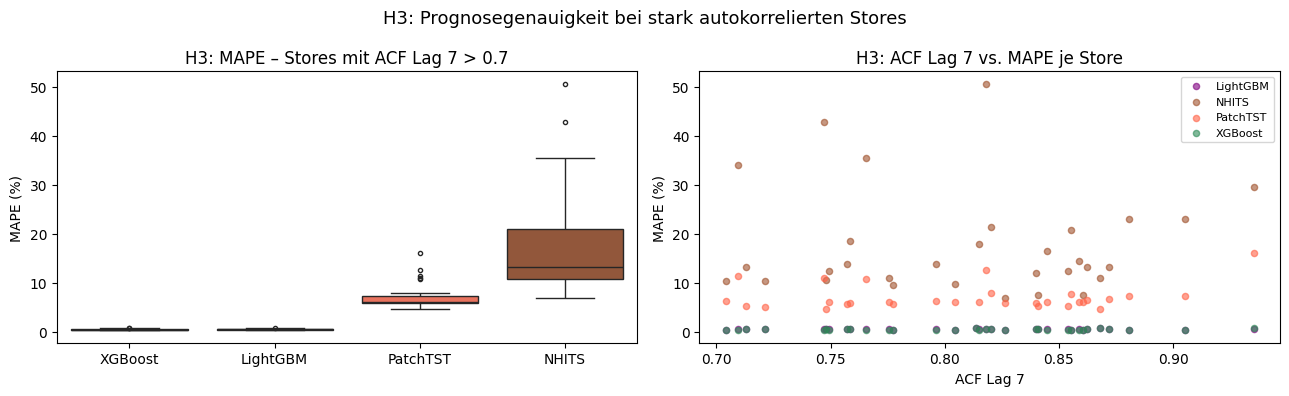

In [17]:
print('H3: Stark autokorrelierte Stores – DL vs. GB (MAPE)')

high_acf  = metrics_df[metrics_df['acf_lag7'] > 0.7]
h3_models = ['XGBoost', 'LightGBM', 'PatchTST', 'NHITS']
h3_df     = high_acf[high_acf['model'].isin(h3_models)]

print(f'Stores mit ACF Lag 7 > 0.7: {high_acf["store_nbr"].nunique()}')
print(h3_df.groupby('model')['MAPE'].mean().round(2).sort_values())

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.boxplot(data=h3_df, x='model', y='MAPE', order=h3_models,
            palette=[MODELL_COLORS[m] for m in h3_models],
            flierprops={'markersize': 3}, ax=axes[0])
axes[0].set_title('H3: MAPE – Stores mit ACF Lag 7 > 0.7', fontsize=12)
axes[0].set_xlabel('')
axes[0].set_ylabel('MAPE (%)')

# ACF Lag 7 vs. MAPE Scatterplot je Modell
for model_name, grp in h3_df.groupby('model'):
    axes[1].scatter(grp['acf_lag7'], grp['MAPE'],
                    label=model_name, alpha=0.6, s=20,
                    color=MODELL_COLORS[model_name])
axes[1].set_title('H3: ACF Lag 7 vs. MAPE je Store', fontsize=12)
axes[1].set_xlabel('ACF Lag 7')
axes[1].set_ylabel('MAPE (%)')
axes[1].legend(fontsize=8)

plt.suptitle('H3: Prognosegenauigkeit bei stark autokorrelierten Stores', fontsize=13)
plt.tight_layout()
plt.show()

## H4: Wenn exogene Faktoren ohne relevante lineare oder nicht-lineare Korrelationen integriert werden, dann führt dies unabhängig von der Modellarchitektur zu keiner signifikanten Verbesserung der Prognosegüte.

H4: Exogene Faktoren – NHITS (mit) vs. PatchTST (ohne)
             MAE   MAPE
model                  
LightGBM    9.66   0.59
NHITS     249.33  18.46
PatchTST  109.17   7.45
XGBoost     9.00   0.54


C:\Users\maxkr\AppData\Local\Temp\ipykernel_20780\1003214194.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=h4_df, x='model', y=metric, order=h4_models,
C:\Users\maxkr\AppData\Local\Temp\ipykernel_20780\1003214194.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=h4_df, x='model', y=metric, order=h4_models,


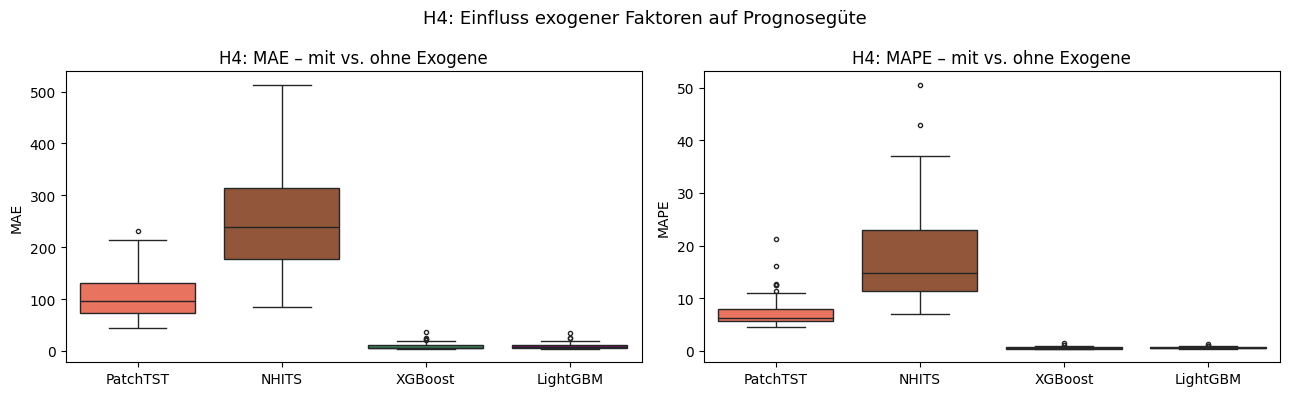

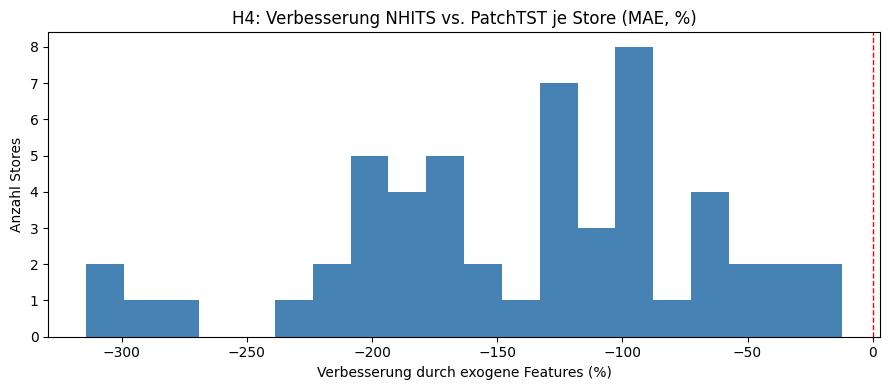

Stores mit Verbesserung durch Exogene: 0 von 53


In [19]:
print('H4: Exogene Faktoren – NHITS (mit) vs. PatchTST (ohne)')

h4_models = ['PatchTST', 'NHITS', 'XGBoost', 'LightGBM']
h4_df     = metrics_df[metrics_df['model'].isin(h4_models)]

print(h4_df.groupby('model')[['MAE', 'MAPE']].mean().round(2))

# Verbesserung NHITS vs. PatchTST je Store
pt_mae  = metrics_df[metrics_df['model'] == 'PatchTST'].set_index('store_nbr')['MAE']
nhi_mae = metrics_df[metrics_df['model'] == 'NHITS'].set_index('store_nbr')['MAE']
improvement = ((pt_mae - nhi_mae) / pt_mae * 100).rename('Verbesserung (%)')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for i, metric in enumerate(['MAE', 'MAPE']):
    sns.boxplot(data=h4_df, x='model', y=metric, order=h4_models,
                palette=[MODELL_COLORS[m] for m in h4_models],
                flierprops={'markersize': 3}, ax=axes[i])
    axes[i].set_title(f'H4: {metric} – mit vs. ohne Exogene', fontsize=12)
    axes[i].set_xlabel('')

plt.suptitle('H4: Einfluss exogener Faktoren auf Prognosegüte', fontsize=13)
plt.tight_layout()
plt.show()

# Verbesserung je Store als Histogramm
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(improvement.dropna(), bins=20, color='steelblue', edgecolor='none')
ax.axvline(0, color='red', linestyle='--', linewidth=1)
ax.set_title('H4: Verbesserung NHITS vs. PatchTST je Store (MAE, %)', fontsize=12)
ax.set_xlabel('Verbesserung durch exogene Features (%)')
ax.set_ylabel('Anzahl Stores')
plt.tight_layout()
plt.show()

print(f'Stores mit Verbesserung durch Exogene: '
      f'{(improvement > 0).sum()} von {len(improvement)}')

## H6: Wenn eine globale Modellierung aller Filialen erfolgt, dann weisen Deep-Learning-Architekturen bei Filialen mit hoher Varianz eine höhere Generalisierungsfähigkeit und geringere Out-of-Sample-Fehler auf als baumbasierte Verfahren.

                        MAE   MAPE
model    store_type               
LightGBM A            20.28   0.63
         B             9.46   0.55
         C             5.63   0.61
         D             8.53   0.59
         E             6.39   0.50
NHITS    A           362.67  11.75
         B           264.89  16.93
         C           195.77  22.23
         D           210.37  16.47
         E           367.76  29.79
PatchTST A           185.82   5.74
         B           116.47   7.11
         C            67.18   7.48
         D           103.97   7.76
         E           122.08  10.02
XGBoost  A            19.94   0.61
         B             8.36   0.48
         C             5.10   0.56
         D             7.91   0.55
         E             5.21   0.41


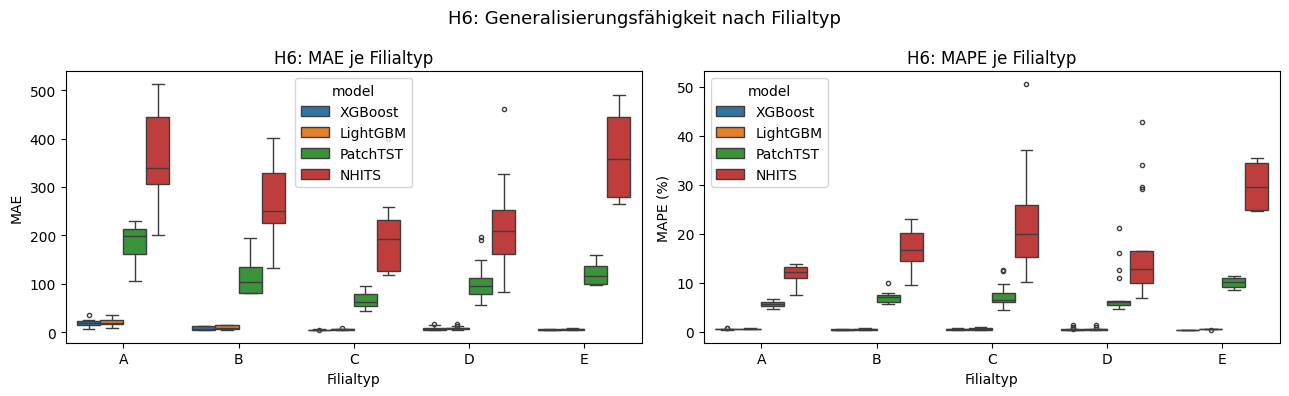

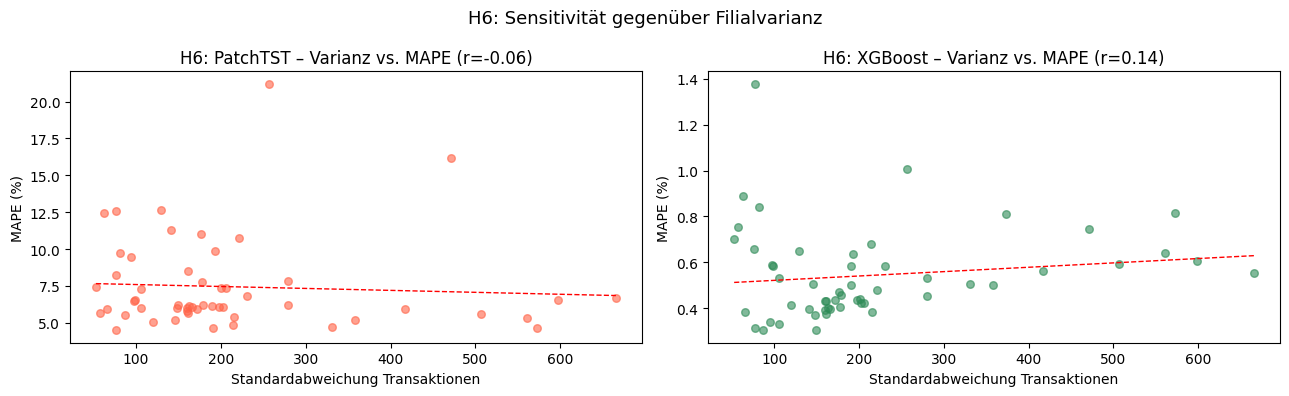

In [20]:
h6_models  = ['XGBoost', 'LightGBM', 'PatchTST', 'NHITS']
h6_df      = metrics_df[metrics_df['model'].isin(h6_models)]
type_order = [t for t in ['A', 'B', 'C', 'D', 'E']
              if t in h6_df['store_type'].unique()]

print(h6_df.groupby(['model', 'store_type'])[['MAE', 'MAPE']]
      .mean().round(2).sort_index())

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for i, metric in enumerate(['MAE', 'MAPE']):
    sns.boxplot(data=h6_df, x='store_type', y=metric,
                hue='model', hue_order=h6_models,
                order=type_order,
                flierprops={'markersize': 3}, ax=axes[i])
    axes[i].set_title(f'H6: {metric} je Filialtyp', fontsize=12)
    axes[i].set_xlabel('Filialtyp')
axes[0].set_ylabel('MAE')
axes[1].set_ylabel('MAPE (%)')
plt.suptitle('H6: Generalisierungsfähigkeit nach Filialtyp', fontsize=13)
plt.tight_layout()
plt.show()

# Varianz vs. MAPE je Modell
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for i, model_name in enumerate(['PatchTST', 'XGBoost']):
    grp = metrics_df[metrics_df['model'] == model_name]
    axes[i].scatter(grp['std_true'], grp['MAPE'],
                    color=MODELL_COLORS[model_name], alpha=0.6, s=30)
    # Regressionslinie
    z = np.polyfit(grp['std_true'], grp['MAPE'], 1)
    p = np.poly1d(z)
    x_line = np.linspace(grp['std_true'].min(), grp['std_true'].max(), 100)
    axes[i].plot(x_line, p(x_line), color='red', linewidth=1, linestyle='--')
    corr = grp['std_true'].corr(grp['MAPE'])
    axes[i].set_title(f'H6: {model_name} – Varianz vs. MAPE (r={corr:.2f})',
                      fontsize=12)
    axes[i].set_xlabel('Standardabweichung Transaktionen')
    axes[i].set_ylabel('MAPE (%)')
plt.suptitle('H6: Sensitivität gegenüber Filialvarianz', fontsize=13)
plt.tight_layout()
plt.show()